# 06 · Observations and conclusions

The three analyses each answer one question. Read together they tell a single story, and the story
is not the one the national headline suggests.

This notebook assembles it, ties every claim to the number that supports it, and states plainly what
this data cannot show.

## Setup

In [1]:
import sys
from pathlib import Path

# Walk up until src/csbc.py is found, so the notebook runs whether Jupyter was started
# in the project root or in src/. Nothing here depends on an absolute path.
_here = Path.cwd().resolve()
_root = next(p for p in (_here, *_here.parents) if (p / "src" / "csbc.py").exists())
sys.path.insert(0, str(_root / "src"))

import pandas as pd
import matplotlib.pyplot as plt

import csbc

csbc.ensure_dirs()
csbc.apply_chart_theme()

pd.set_option("display.width", 120)
pd.set_option("display.max_colwidth", 48)

print(f"project: {csbc.ROOT.name}/")
print(f"raw data: {len(sorted(csbc.RAW_DIR.glob('*.csv')))} quarterly CSVs in data/raw")

project: business_data_lab_assignment/
raw data: 4 quarterly CSVs in data/raw


In [2]:
csbc_data = csbc.load_combined()
QUARTERS = csbc.sort_quarters(csbc_data["Quarter"])

print(f"{len(csbc_data):,} rows | quarters: {', '.join(QUARTERS)}")

9,408 rows | quarters: Q3 2023, Q4 2023, Q1 2024, Q2 2024


## The story in four steps

### Step 1 — What happened: the top line improved

Into Q2 2024, three of the four metrics reached four-quarter highs — sales **+2.9 pp**, employment
and profitability **+2.1 pp** each. Investment alone stayed flat at 17.6%, below its Q3 2023 level.

Read on its own, this looks like a recovery with one puzzling laggard.

### Step 2 — Why investment is not simply a laggard

The obvious story — "capital spending follows sales with a delay" — is intuitive, and this data
argues against it on **two independent measures**:

1. **Answer rates.** Employment's three response shares sum to exactly 100. Investment's sum to
   about 84, so roughly **one business in six gives no directional answer at all**. The likeliest
   reason is that many firms simply have no investment plan to report.
2. **Correlation.** Investment's expectations are **statistically independent** of the other three
   (mean r = 0.10, against 0.32–0.36 for each of the others).

If investment were a lagged version of the operating cycle, it would still be *correlated* with it,
just offset. It is not. Investment is a **separate decision**, made on different grounds — so its
flatness is not a delay to wait out.

### Step 3 — What that reveals: entrenched margin pessimism

Notebook `04` found **12 of 13 industries** expecting profitability to fall in Q2 2024 — and, looking
across all four quarters, that essentially **every** industry has expected it in **every** quarter of
the window.

The direction is encouraging: the mean balance improved from **−23.9 pp to −17.1 pp**, and Q2 2024 is
the least bad of the four. Profitability improved *alongside* sales, not against it, which is what
notebook `02`'s r = 0.58 predicts. **The level is the finding, not a divergence in direction.**

What matters is that even at the best reading in the window, businesses expect to **sell more and
keep less**, and have done so for a year. That is a cost-side story rather than a demand-side one, and
it explains step 2 better than a sudden squeeze would: a firm that has expected thinner margins for
four straight quarters has little reason to commit capital, whatever its sales outlook does.

### Step 4 — And it was not shared evenly

The national improvement was concentrated: **Ontario (+1.6 pp)** and **Quebec (+2.2 pp)** both came
in below the national **+2.9 pp**, which was lifted by Alberta, British Columbia and Atlantic Canada.
**Manitoba declined.** Most Canadian businesses sit in the provinces that improved least.

## The story in one figure

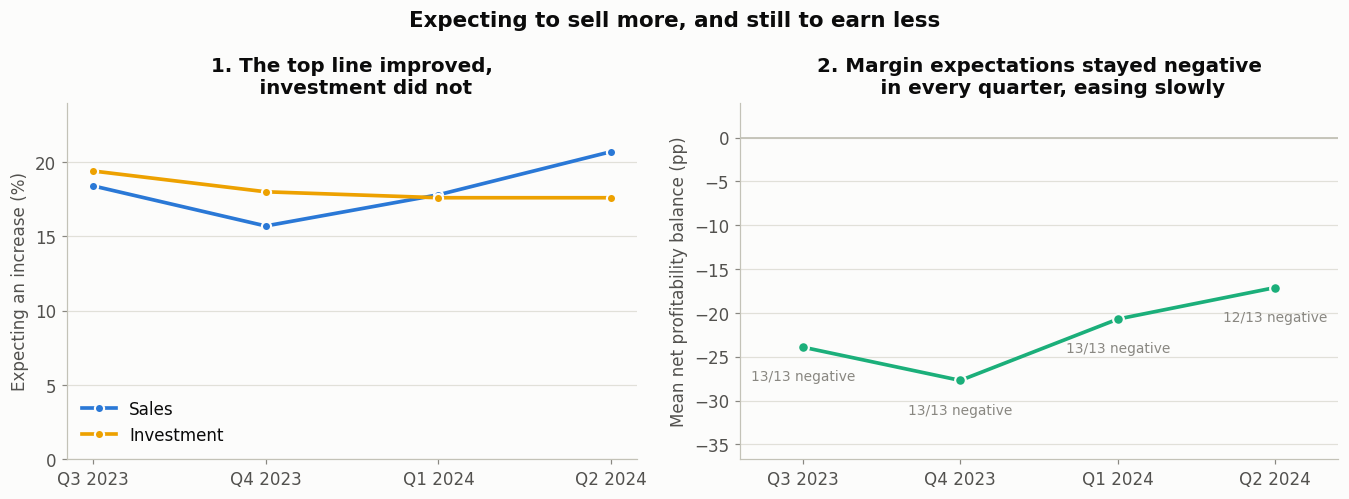

In [3]:
# One figure carrying the whole argument: the national top line rising while sector
# margin expectations sit almost entirely below zero.
national = csbc.national_increase_table(csbc_data)
sectors = csbc.sector_balance_table(csbc_data, "Q2 2024")

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.6),
                         gridspec_kw={"width_ratios": [1, 1.05]})

# Left: sales up, investment flat.
for metric, style in [("Sales", "-"), ("Investment", "-")]:
    axes[0].plot(range(len(national)), national[metric], style,
                 color=csbc.SERIES_COLOR[metric], linewidth=2.4, marker="o",
                 markersize=6, markeredgecolor=csbc.SURFACE, markeredgewidth=1.4,
                 label=metric, zorder=3)
axes[0].set_xticks(range(len(national)), list(national.index))
axes[0].set_ylim(0, 24)
axes[0].set_ylabel("Expecting an increase (%)")
axes[0].set_title("1. The top line improved,\n    investment did not")
axes[0].grid(axis="y")
axes[0].set_axisbelow(True)
axes[0].legend(frameon=False, loc="lower left")

# Right: margin expectations - negative in every quarter, but easing. Showing the trend
# rather than Q2 alone is the point: a single quarter cannot say whether this is new.
trend = csbc.sector_balance_trend(csbc_data)
axes[1].axhline(0, color=csbc.BASELINE, linewidth=1.2, zorder=2)
axes[1].plot(range(len(trend)), trend["mean_balance_pp"],
             color=csbc.SERIES_COLOR["Profitability"], linewidth=2.4, marker="o",
             markersize=7, markeredgecolor=csbc.SURFACE, markeredgewidth=1.4, zorder=3)
for i, (value, neg, total) in enumerate(
    zip(trend["mean_balance_pp"], trend["negative"], trend["industries"])
):
    axes[1].annotate(f"{neg}/{total} negative", xy=(i, value), xytext=(0, -22),
                     textcoords="offset points", ha="center", fontsize=9,
                     color=csbc.MUTED)
axes[1].set_xticks(range(len(trend)), list(trend.index))
axes[1].set_xlim(-0.4, len(trend) - 0.6)
axes[1].set_ylim(trend["mean_balance_pp"].min() - 9, 4)
axes[1].set_ylabel("Mean net profitability balance (pp)")
axes[1].set_title("2. Margin expectations stayed negative\n"
                  "    in every quarter, easing slowly")
axes[1].grid(axis="y")
axes[1].set_axisbelow(True)

fig.suptitle("Expecting to sell more, and still to earn less",
             fontsize=14, fontweight="semibold")
fig.tight_layout()
fig.savefig(csbc.OUTPUT_DIR / "conclusions_story.png")
plt.show()

## Every claim, and the number behind it

In [4]:
# Every claim in the story, next to the number that supports it, computed rather than typed.
correlations = csbc.metric_matrix(csbc_data).corr()
regional = csbc.regional_table(csbc_data, "Q1 2024", "Q2 2024")
sectors = csbc.sector_balance_table(csbc_data, "Q2 2024")
trend = csbc.sector_balance_trend(csbc_data)
national = csbc.national_increase_table(csbc_data)

# The national, all-industries composition - the same figures the donuts in notebook 02
# showed. (The all-cells average residual is higher, 18.5% for Investment, because small
# volatile cells pull it up; the national figure is the one the story quotes.)
composition = csbc.composition_table(csbc_data, "Q1 2024")

evidence = pd.DataFrame([
    ("Sales expectations rose Q1->Q2",
     f"{national.loc['Q2 2024', 'Sales'] - national.loc['Q1 2024', 'Sales']:+.1f} pp", "03"),
    ("Investment expectations were flat",
     f"{national.loc['Q2 2024', 'Investment'] - national.loc['Q1 2024', 'Investment']:+.1f} pp",
     "03"),
    ("No direction given on Investment (Canada, all industries)",
     f"{composition.loc['Investment', csbc.NO_ANSWER]:.1f}% of businesses", "01, 02"),
    ("No direction given on Employment (Canada, all industries)",
     f"{composition.loc['Employment', csbc.NO_ANSWER]:.1f}% of businesses", "01, 02"),
    ("Investment's mean correlation with the others",
     f"r = {correlations['Investment'].drop('Investment').mean():.2f}", "02"),
    ("Sales-Profitability correlation (strongest pair)",
     f"r = {correlations.loc['Sales', 'Profitability']:.2f}", "02"),
    ("Industries expecting profitability to fall",
     f"{int((sectors['net_balance_pp'] < 0).sum())} of {len(sectors)}", "04"),
    ("Weakest industry balance",
     f"{sectors['net_balance_pp'].min():+.1f} pp ({sectors['net_balance_pp'].idxmin()})", "04"),
    ("Quarters in which every industry was negative",
     f"{int((trend['negative'] == trend['industries']).sum())} of {len(trend)}", "04"),
    ("Mean margin balance, first to last quarter",
     f"{trend['mean_balance_pp'].iloc[0]:+.1f} -> {trend['mean_balance_pp'].iloc[-1]:+.1f} pp", "04"),
    ("Jurisdictions improving on sales",
     f"{int((regional.drop(index='Canada')['change_pp'] > 0).sum())} of 13", "05"),
    ("Ontario vs national change",
     f"{regional.loc['Ontario', 'change_pp']:+.1f} pp vs "
     f"{regional.loc['Canada', 'change_pp']:+.1f} pp", "05"),
], columns=["Claim", "Evidence", "Notebook"])

evidence

,Claim,Evidence,Notebook
0,Sales expectations rose Q1->Q2,+2.9 pp,03
1,Investment expectations were flat,+0.0 pp,03
2,"No direction given on Investment (Canada, al...",16.1% of businesses,"01, 02"
3,"No direction given on Employment (Canada, al...",0.0% of businesses,"01, 02"
4,Investment's mean correlation with the others,r = 0.10,02
5,Sales-Profitability correlation (strongest p...,r = 0.58,02
6,Industries expecting profitability to fall,12 of 13,04
7,Weakest industry balance,"-40.9 pp (Agriculture, forestry, fishing and...",04
8,Quarters in which every industry was negative,3 of 4,04
9,"Mean margin balance, first to last quarter",-23.9 -> -17.1 pp,04


## What I would tell a stakeholder

**In one line:** business expectations improved in Q2 2024, but the improvement is narrower and
shallower than the national figure suggests — firms still expect to sell more and earn less, and they
are not planning to invest.

**Three things I would act on:**

1. **Read the level, not just the change.** Q2 2024 is genuinely the best of the four quarters on
   margin expectations — but 12 of 13 industries still expect profitability to fall, and every
   industry has expected it in every quarter of the window. A year of thin expected margins shapes
   behaviour more than one quarter of improvement does.
2. **Stop waiting for investment to follow.** The data gives no reason to expect capital spending to
   pick up mechanically as sales expectations improve — the two are statistically unrelated here. If
   investment is a policy goal, it needs to be addressed on its own terms.
3. **Use provincial detail, not the national average, for regional decisions.** A member in Ontario
   experienced roughly half the improvement the national number implies; one in Manitoba experienced
   none.

**Where I would look next**, given the cost-side reading: input costs, wage pressure, financing
costs and pricing power — none of which are in this dataset. That is a hypothesis this survey
generates but cannot test.

## What this data cannot support

Being explicit about the limits is part of the analysis:

- **No causality.** Every relationship here is an association across survey cells. The
  margin-squeeze reading is the most plausible explanation of the pattern, not a demonstrated
  mechanism.
- **No statistical significance.** The extract has percentages but no sample sizes, weights,
  confidence intervals or margins of error, so no claim here is tested for significance. That is why
  the volatility column in notebook `05` matters — it is the closest available proxy for "how much
  should I trust this movement".
- **Four quarters is not a trend.** It supports quarter-to-quarter comparison, not a cycle claim.
- **Expectations, not outcomes.** The survey records what businesses *expect*. Whether those
  expectations were realised is outside this data.
- **Correlations computed across cells, not over time.** With four quarters there are too few
  periods for a time-series correlation; the associations in notebook `02` are cross-sectional, so
  they describe how the metrics vary *together across groups*, not how they lead or lag each other.
- **The seven missing values remain missing.** Notebook `01` showed they cannot be reconstructed;
  every published figure here avoids depending on them.

---

**Next:** `07_quarterly_refresh_pipeline.ipynb` — how quarter five enters this analysis without
manual rework.

---

*All logic lives in [`csbc.py`](csbc.py) so the notebooks, the tests and the pipeline CLI
share one implementation.*